# Boosting

## Importación de librerías y paquetes y definición de constantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# To save models
import json
import pickle
# Modelado
from xgboost import XGBClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
# Métricas
from sklearn.metrics import confusion_matrix, recall_score
from utils import get_classifier_metrics
from sklearn.model_selection import GridSearchCV, cross_val_score
# Warnings
import warnings

In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Vamos a probar tres enfoques diferentes para la generación de este modelo:

1. Dataset truncado
2. Dataset con valores nulos remplazados por la moda
3. Dataset con valores nulos remplazados por los k-nearest neighbors


## 1. Dataset truncado:

### Cargamos el dataset procedente del eda previo

In [3]:
df_train_filtrado = pd.read_csv("../data/processed/data-train-filtrado.csv")
df_test_filtrado = pd.read_csv("../data/processed/data-test-filtrado.csv")

### Generamos los conjuntos de train y test

In [4]:
X_train_filtrado = df_train_filtrado.drop(["Outcome"], axis = 1)
y_train_filtrado = df_train_filtrado["Outcome"]
X_test_filtrado = df_test_filtrado.drop(["Outcome"], axis = 1)
y_test_filtrado = df_test_filtrado["Outcome"]

### Modelado y Ajuste

In [5]:
xg_classifier_model_filtrado = XGBClassifier(random_state = 24)
xg_classifier_model_filtrado.fit(X_train_filtrado, y_train_filtrado)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### Predicción 

In [6]:
y_pred_test_fil = xg_classifier_model_filtrado.predict(X_test_filtrado)
y_pred_test_fil

array([0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0])

In [7]:
y_pred_train_fil = xg_classifier_model_filtrado.predict(X_train_filtrado)
y_pred_train_fil

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,

#### Matriz de confusión

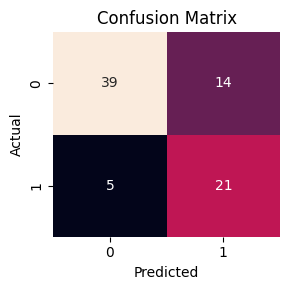

In [8]:
diabetes_cm = confusion_matrix(y_test_filtrado, y_pred_test_fil)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Métricas

In [9]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.759494,0.759494,0.759494,0.759494


In [10]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.759494,0.746324,0.743182,0.771771


In [11]:
get_classifier_metrics(y_pred_test_fil, y_test_filtrado, y_pred_train_fil, y_train_filtrado, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.759494,0.766078,0.792117,0.759494


## 2. Dataset con valores nulos remplazados por la moda

In [12]:
df_train_mode = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-train-mode.csv")
df_test_mode = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-test-mode.csv")

### Generamos los conjuntos de train y test

In [13]:
X_train_mode = df_train_mode.drop(["Outcome"], axis = 1)
y_train_mode = df_train_mode["Outcome"]
X_test_mode = df_test_mode.drop(["Outcome"], axis = 1)
y_test_mode = df_test_mode["Outcome"]

### Modelado y Ajuste

In [14]:
xg_classifier_model_mode = XGBClassifier(random_state = 24)
xg_classifier_model_mode.fit(X_train_mode, y_train_mode)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### Predicción 

In [15]:
y_pred_test_mode = xg_classifier_model_mode.predict(X_test_mode)
y_pred_test_mode

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [16]:
y_pred_train_mode = xg_classifier_model_mode.predict(X_train_mode)
y_pred_train_mode

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,

#### Matriz de confusión

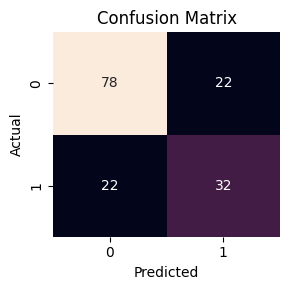

In [17]:
diabetes_cm = confusion_matrix(y_test_mode, y_pred_test_mode)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Métricas

In [18]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.714286,0.714286,0.714286,0.714286


In [19]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.714286,0.686296,0.686296,0.686296


In [20]:
get_classifier_metrics(y_pred_test_mode, y_test_mode, y_pred_train_mode, y_train_mode, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.714286,0.714286,0.714286,0.714286


## 3. Dataset con valores nulos remplazados por los k-nearest neighbors

In [21]:
df_train_kn = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-train-kn.csv")
df_test_kn = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/processed/data-test-kn.csv")

### Generamos los conjuntos de train y test

In [22]:
X_train = df_train_kn.drop(["Outcome"], axis = 1)
y_train = df_train_kn["Outcome"]
X_test = df_test_kn.drop(["Outcome"], axis = 1)
y_test = df_test_kn["Outcome"]

### Modelado y Ajuste

In [23]:
xg_classifier_model = XGBClassifier(random_state = 24)
xg_classifier_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### Predicción 

In [24]:
y_pred_test = xg_classifier_model.predict(X_test)
y_pred_test

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [25]:
y_pred_train = xg_classifier_model.predict(X_train)
y_pred_train

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,

#### Matriz de confusión

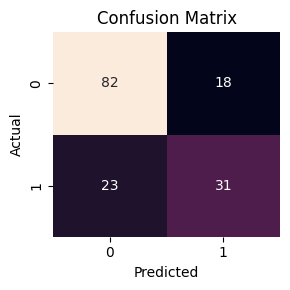

In [26]:
diabetes_cm = confusion_matrix(y_test, y_pred_test)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Métricas

In [27]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.733766,0.733766,0.733766,0.733766


In [28]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.733766,0.700971,0.706803,0.697037


In [29]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,1.000000,1.000000,1.000000,1.000000
Test set,0.733766,0.730551,0.728951,0.733766


## Buscamos los mejores parámetros con `GridSearchCV`

### Definición de parámetros y métricas

In [30]:
param_grid = {'n_estimators': [10, 50, 100, 200, 300],
              'max_depth': [3, 5, 7, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],
              'max_features': ['sqrt', 'log2', None]
}
grid_search = GridSearchCV(estimator=xg_classifier_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1
)


### Entrenamiento de la cuadrícula

In [31]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


### Mejores parámetros

In [32]:
grid_search.best_estimator_

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [33]:
grid_search.best_params_

{'max_depth': 3,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 10}

### Predicción 

In [34]:
best_model = grid_search.best_estimator_
y_pred_test_grid = best_model.predict(X_test)
y_pred_test_grid

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [35]:
y_pred_train_grid = best_model.predict(X_train)
y_pred_train_grid

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,

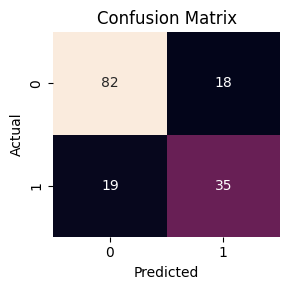

In [36]:
diabetes_cm = confusion_matrix(y_test, y_pred_test_grid)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Métricas

In [37]:
get_classifier_metrics(y_pred_test_grid, y_test, y_pred_train_grid, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.868078,0.868078,0.868078,0.868078
Test set,0.759740,0.759740,0.759740,0.759740


In [38]:
get_classifier_metrics(y_pred_test_grid, y_test, y_pred_train_grid, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.868078,0.853279,0.857183,0.849860
Test set,0.759740,0.735063,0.736129,0.734074


In [39]:
get_classifier_metrics(y_pred_test_grid, y_test, y_pred_train_grid, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.868078,0.867395,0.867117,0.868078
Test set,0.759740,0.759215,0.758756,0.759740


## Añadimos un cuarto enfoque dejando el dataset sin tratar los valores nulos, ya que el boosting con xgboost es robuzto ante estos casos

In [40]:
df_null = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/diabetes.csv")


In [41]:
df_null.loc[df_null['Insulin'] <= 0, 'Insulin'] = np.nan
df_null.loc[df_null['SkinThickness'] <= 0, 'SkinThickness'] = np.nan
df_null.loc[df_null['BloodPressure'] <= 0, 'BloodPressure'] = np.nan

In [42]:
df_null.isnull().sum().sort_values(ascending=False) / len(df_null)

Insulin                     0.486979
SkinThickness               0.295573
BloodPressure               0.045573
Pregnancies                 0.000000
Glucose                     0.000000
BMI                         0.000000
DiabetesPedigreeFunction    0.000000
Age                         0.000000
Outcome                     0.000000
dtype: float64

In [43]:
X_train_null, X_test_null, y_train_null, y_test_null = train_test_split(df_null.drop('Outcome', axis=1), 
                                                                        df_null['Outcome'],
                                                                        test_size=0.2,
                                                                        random_state=24,
                                                                        stratify=df_null['Outcome'])
X_train_null

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
712,10,129,62.0,36.0,NaN,41.2,0.441,38
626,0,125,68.0,NaN,NaN,24.7,0.206,21
157,1,109,56.0,21.0,135.0,25.2,0.833,23
401,6,137,61.0,NaN,NaN,24.2,0.151,55
355,9,165,88.0,NaN,NaN,30.4,0.302,49
...,...,...,...,...,...,...,...,...
381,0,105,68.0,22.0,NaN,20.0,0.236,22
324,2,112,75.0,32.0,NaN,35.7,0.148,21
68,1,95,66.0,13.0,38.0,19.6,0.334,25
704,4,110,76.0,20.0,100.0,28.4,0.118,27


In [44]:
xg_classifier_model_null = XGBClassifier(random_state = 24)
xg_classifier_model_null.fit(X_train_null, y_train_null)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [45]:
y_pred_test_null = xg_classifier_model_null.predict(X_test_null)
y_pred_test_null

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0])

In [46]:
y_pred_train_null = xg_classifier_model.predict(X_train_null)
y_pred_train_null

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0,

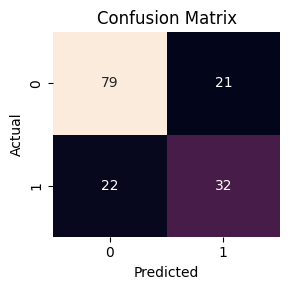

In [47]:
diabetes_cm = confusion_matrix(y_test_null, y_pred_test_null)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(diabetes_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [48]:
get_classifier_metrics(y_pred_test_null, y_test_null, y_pred_train_null, y_train_null) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.923453,0.923453,0.923453,0.923453
Test set,0.720779,0.720779,0.720779,0.720779


In [49]:
get_classifier_metrics(y_pred_test_null, y_test_null, y_pred_train_null, y_train_null, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.923453,0.91599,0.914689,0.917348
Test set,0.720779,0.69210,0.692976,0.691296


In [50]:
get_classifier_metrics(y_pred_test_null, y_test_null, y_pred_train_null, y_train_null, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.923453,0.923575,0.923745,0.923453
Test set,0.720779,0.720169,0.719621,0.720779


## Comparativa entre modelos

In [51]:
metricas = {'recall filtrado': recall_score(y_test_filtrado, y_pred_test_fil, average='micro'),
            'recall mode': recall_score(y_test_mode, y_pred_test_mode, average='micro'),
            'recall knn': recall_score(y_test, y_pred_test, average='micro'),
            'recall gridsearch': recall_score(y_test, y_pred_test_grid, average='micro'),
            'recall null': recall_score(y_test_null, y_pred_test_null, average='micro')
}
metricas

{'recall filtrado': 0.759493670886076,
 'recall mode': 0.7142857142857143,
 'recall knn': 0.7337662337662337,
 'recall gridsearch': 0.7597402597402597,
 'recall null': 0.7207792207792207}

| Modelo           | Recall     |
|------------------|------------|
| Filtrado         | 0.7595     |
| Mode             | 0.7143     |
| KNN              | 0.7338     |
| GridSearch       | 0.7597     |
| Null             | 0.7208     |

### Observamos cierta mejora en los modelos pero nada significativo, siguen estando por debajo de un valor que podamos considerar suficiente para meter en producción

## Guardado de modelos

In [52]:
models = {'xg_classifier_model_filtrado' : xg_classifier_model_filtrado,
          'xg_classifier_model_mode' : xg_classifier_model_mode,
          'xg_classifier_model' : xg_classifier_model,
          'xg_classifier_model_null' : xg_classifier_model_null  
          }
with open('C:/Users/Simón/sayons-intro-ml-new/models/modelos-boosting.pkl', 'wb') as file:
    pickle.dump(models, file)